In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats


In [2]:
df = pd.read_csv("df_assignment.csv")


focus_crime = [
    "larceny theft",
    "motor vehicle theft",
    "robbery",
    "assault",
    "drug offense",
    "weapons offense",
    "vandalism",
    "suicide",
]

In [3]:
# convert datetime column to proper datetime format
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df = df.dropna(subset=["datetime"])

# extract time information
df["hour"] = df["datetime"].dt.hour
df["minute"] = df["datetime"].dt.minute
df["weekday"] = df["datetime"].dt.weekday

df_focus = df[df["category"].isin(focus_crime)].copy()

## Assignment 1.3: Visualizing Distributions

### 1.3A Jitter plot

Pick one of your Personal Focus Crimes and a suitable time interval (somewhere between a month and 6 months, depending on how common the crime is). Create a jitter plot of the incident times during a single hour (e.g. 13:00–14:00): let time run along the  x-axis and add vertical jitter.

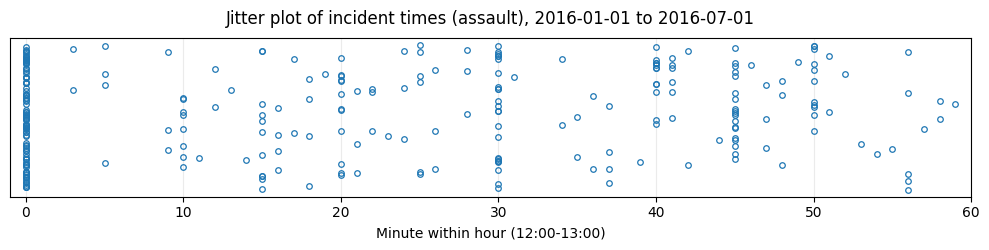

In [4]:
crime = "assault"
start = "2016-01-01"
end   = "2016-07-01"
target_hour = 12

sub = df_focus[
    (df_focus["category"] == crime) &
    (df_focus["datetime"] >= start) &
    (df_focus["datetime"] < end) &
    (df_focus["hour"] == target_hour)
].copy()

minutes = sub["minute"].dropna().to_numpy()

# vertical jitter
y = np.random.uniform(-0.12, 0.12, size=len(minutes))

plt.figure(figsize=(10, 2.6))
plt.plot(minutes, y, "o", markersize=4, markerfacecolor="none", markeredgewidth=0.9)

plt.xlim(-1, 60)
plt.xlabel(f"Minute within hour ({target_hour:02d}:00-{(target_hour+1)%24:02d}:00)")
plt.yticks([])
plt.title(f"Jitter plot of incident times ({crime}), {start} to {end}", pad=10)

plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

The jitter plot shows the distribution of assault incidents from the hours 12:00-13:00. Each point represents an incident and is sorted by the minute on the x-axis. A small vertical jitter is added so that overlapping points can be seen more clearly.

The plot shows heavy clustering at certain minutes, especially at the start of the hour and around other popular rounded minute values (10,15,20,30,40,45,50). This suggests that incident times in the dataset are not always recorded with exact precision. Instead, they are rounded or estimated to convenient times which are easily remembered.

This pattern indicates that the time information in the dataset may have a limited precision. Rather than representing the exact minute an incident occurrs, the recorded times may be approximated or rounded estimates which were entered by officers.

### 1.3B Probability Plot (QQ Plot)

Using the same geographic data from Part B, create a probability plot (QQ plot) for the latitude distribution of each of your two crime types. (scipy.stats.probplot is your friend here.)

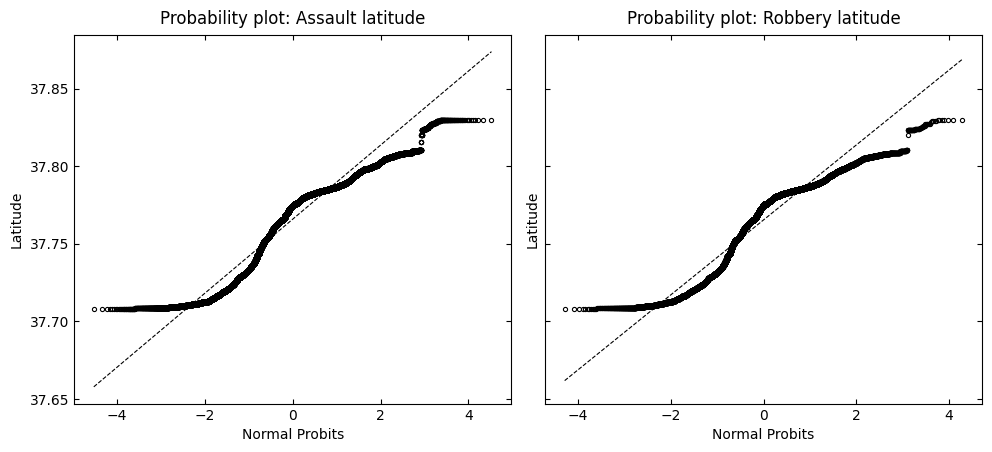

In [5]:
crime1 = "assault"
crime2 = "robbery"

geo = df[
    df["latitude"].between(37.0, 38.5) &
    df["longitude"].between(-123.0, -121.5)
].copy()

lat1 = geo.loc[geo["category"] == crime1, "latitude"].dropna().to_numpy()
lat2 = geo.loc[geo["category"] == crime2, "latitude"].dropna().to_numpy()

def probability_plot(ax, data, title):
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist="norm", fit=True)

    ax.plot(osm, osr, "o", ms=3, mfc="none", mec="k", mew=0.8)
    xline = np.array([osm.min(), osm.max()])
    ax.plot(xline, intercept + slope * xline, "k--", lw=0.8)

    ax.set_title(title, pad=8)
    ax.set_xlabel("Normal Probits")
    ax.set_ylabel("Latitude")
    ax.tick_params(direction="in", top=True, right=True)

fig, ax = plt.subplots(1, 2, figsize=(10, 4.6), sharey=True)

probability_plot(ax[0], lat1, "Probability plot: Assault latitude")
probability_plot(ax[1], lat2, "Probability plot: Robbery latitude")

plt.tight_layout(pad=1.0)
plt.show()

The probability plots compare the observed latitude values to a normal (Gaussian) distribution.

If all points followed the straight line exactly, it would mean that the latitude values are normally distributed.
This would mean that the spatial distribution of crimes along the latitude of the city follows a bell-shaped pattern.

In both plots, the points deviate from the straight line in the lower and upper tails, creating an S-shaped curve.
The middle of the distribution follows the line more closely than the rest.

The deviation from the normal distribution suggests that the crime locations are not evenly distributed across the city's latitude.
Instead, the incidents tend to cluster in specific areas of the city, likely in neighborhoods with higher crime levels.
Since San Francisco has geographic boundaries and concentrated areas of crime, the spatial distribution of the incidents does not follow a perfect normal distribution.

### 1.3C Box plots of time-of-day

For each of your Personal Focus Crimes, extract the time-of-day of every incident.
Create box plots showing the time-of-day distribution for all your Personal Focus Crimes side by side.

C:\Users\victo\AppData\Local\Temp\ipykernel_44956\1181878263.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


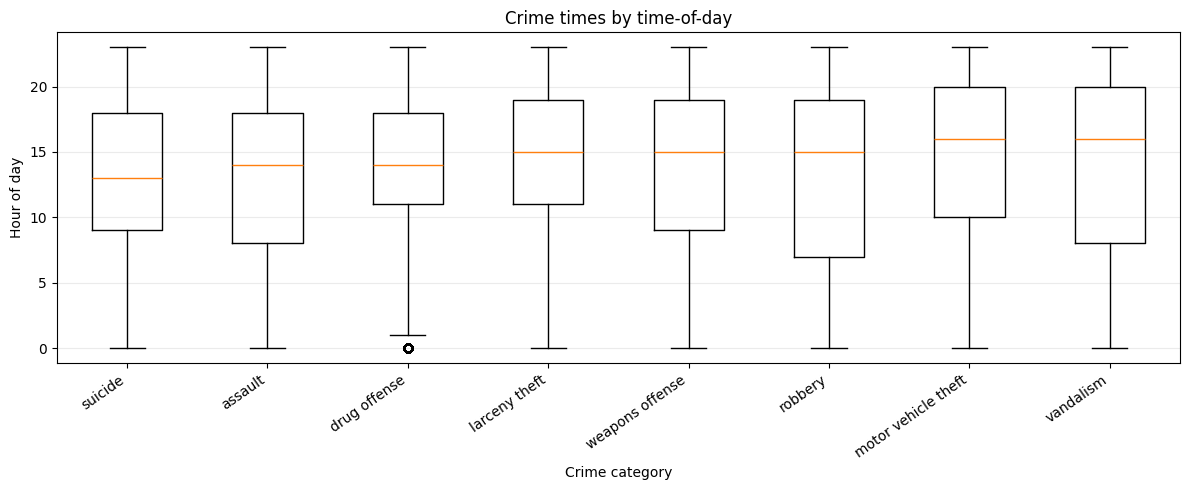

In [6]:
# The order is based on the median (ascending order)
order = (
    df_focus.groupby("category")["hour"]
    .median()
    .sort_values()
    .index
)

data = [
    df_focus.loc[df_focus["category"] == crime, "hour"].dropna()
    for crime in order
]

plt.figure(figsize=(12,5))

plt.boxplot(
    data,
    labels=order,
    showfliers=True
)

plt.xticks(rotation=35, ha="right")

plt.xlabel("Crime category")
plt.ylabel("Hour of day")
plt.title("Crime times by time-of-day")

plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

The box plots show how the time-of-day distribution differs between the crime categories. Most of the crimes have median times in the afternoon or early evening, around 14:00–16:00. They have been sorted by the median in ascending order to allow for better analysis. Some crimes, such as motor vehicle theft and vandalism, appear to occur slightly later in the day, while others like assault and suicide have earlier median times. However, the interquartile ranges of all the crimes are fairly wide, which suggests that the crimes occur throughout the day rather than being restricted to a narrow timeframe.

A limitation of the box plot that time-of-day is a circular variable. The hours of the day go from 23:00 back to 00:00, but the box plot treats time as a linear scale from 0 to 23. This means that incidents that happen close to midnight can appear far apart in the plot even though they actually happen close to each other. For example, crimes that occur at 23:50 and 00:10 are only twenty minutes apart but would appear on opposite ends of the scale. This means that the box plot doesn't handle the wrap-around at midnight and this slightly distorts the interpretation of crimes that peak late at night.